# Nicel Sonuçlar — Bulgular Grafikleri

4 deneyin sonuç özetleri, tezde Bulgular bölümünde kullanılacak bar/line charts.

**Ne üretir:**
- `Exp_backbone_chart.png` — Omurga karşılaştırması (8 model)
- `Exp_unfreeze_chart.png` — Katman açma (ResNet-18, ResNet-50 × 3 strateji)
- `Exp_swin_unfreeze_chart.png` — Aşama açma (Swin-T × 3 strateji)
- `Exp_pretrained_chart.png` — Ön eğitimli ağırlıklar (5 kaynak, ResNet-50)

**Format:**
- Türkçe virgüllü ondalık (eksen ve data labels)
- Serif font (Times/Liberation Serif)
- Data labels her bar/noktada
- Tez kenar sınırına uygun genişlik

**Çıktı dizini:** `figures/quantitative_results/` (LaTeX referansları değişmez)

**Bağımlılıklar:** MLflow (CPU). GPU gerekmez.


### 0. Kurulum

In [1]:
import sys
import re
import warnings
from collections import defaultdict
from pathlib import Path

import mlflow
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

mlflow.set_tracking_uri(str(PROJECT_ROOT / "mlruns"))
client = mlflow.tracking.MlflowClient()
exp = client.get_experiment_by_name("woodland-fss")

FIGURES_DIR = PROJECT_ROOT / "figures" / "quantitative_results"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Ortak stil ayarları — tüm grafiklerde tutarlı
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman", "Liberation Serif", "DejaVu Serif"]
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams["figure.dpi"] = 150

# Türkçe virgüllü ondalık formatter
def tr_format(x, pos, decimals=3):
    return f"{x:.{decimals}f}".replace(".", ",")

COLORS = {
    "fgIoU": "#9b8ce8",  # açık mor
    "mIoU":  "#7dc9a9",  # nane yeşili
    "R50":   "#1e7f3e",  # koyu yeşil
    "R18":   "#4a3d9e",  # koyu mor
    "SwinT": "#2c3e50",  # lacivert
    "SwinT_light": "#27ae60",  # yeşil (mIoU)
}

print(f"MLflow: {mlflow.get_tracking_uri()}")
print(f"Figures: {FIGURES_DIR}")


/home/zehra/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MLflow: /home/zehra/Desktop/woodland/mlruns
Figures: /home/zehra/Desktop/woodland/figures/quantitative_results


### 1. Veri Toplama — Her Yapılandırma İçin 5-Fold fgIoU/mIoU

In [2]:
all_runs = client.search_runs([exp.experiment_id], max_results=500)
test_runs = [r for r in all_runs if r.data.params.get("phase") == "test"]

by_name = defaultdict(list)
for r in test_runs:
    by_name[r.info.run_name].append(r)
latest_test = {n: max(rl, key=lambda x: x.info.start_time) for n, rl in by_name.items()}


def parse_name(name):
    m = re.match(
        r"(?:TEST_)?ProtoNet_(\w+?)(?:_([A-Za-z0-9]+))?_(none|layer3|layer4|stage3|stage4)_fold(\d)_seed-42",
        name,
    )
    if not m:
        return None
    return {
        "backbone": m.group(1),
        "pretrained": m.group(2) or "ImageNetV1",
        "unfreeze": m.group(3),
        "fold": int(m.group(4)),
    }


# {(backbone, pretrained, uf): {fold: {fgIoU, mIoU}}}
config_folds = defaultdict(dict)
for name, r in latest_test.items():
    info = parse_name(name)
    if info is None:
        continue
    ckey = (info["backbone"], info["pretrained"], info["unfreeze"])
    config_folds[ckey][info["fold"]] = {
        "fgIoU": r.data.metrics.get("test_fgIoU"),
        "mIoU":  r.data.metrics.get("test_mIoU"),
    }


def get_stats(backbone, pretrained, uf):
    """Yapılandırma için 5-fold ortalama ve std."""
    folds = config_folds.get((backbone, pretrained, uf), {})
    fg = [v["fgIoU"] for v in folds.values() if v["fgIoU"] is not None]
    mi = [v["mIoU"]  for v in folds.values() if v["mIoU"]  is not None]
    return {
        "fgIoU_mean": np.mean(fg) if fg else np.nan,
        "fgIoU_std":  np.std(fg)  if fg else np.nan,
        "mIoU_mean":  np.mean(mi) if mi else np.nan,
        "mIoU_std":   np.std(mi)  if mi else np.nan,
        "n_folds":    len(fg),
    }


print(f"Toplam yapılandırma: {len(config_folds)}")
print(f"Beklenen: 18 yapılandırma × 5 fold = 90 run")


Toplam yapılandırma: 18
Beklenen: 18 yapılandırma × 5 fold = 90 run


### 2. Grafik 1 — Omurga Karşılaştırması (8 model, dondurulmuş)

Kaydedildi: /home/zehra/Desktop/woodland/figures/quantitative_results/Exp_backbone_chart.png


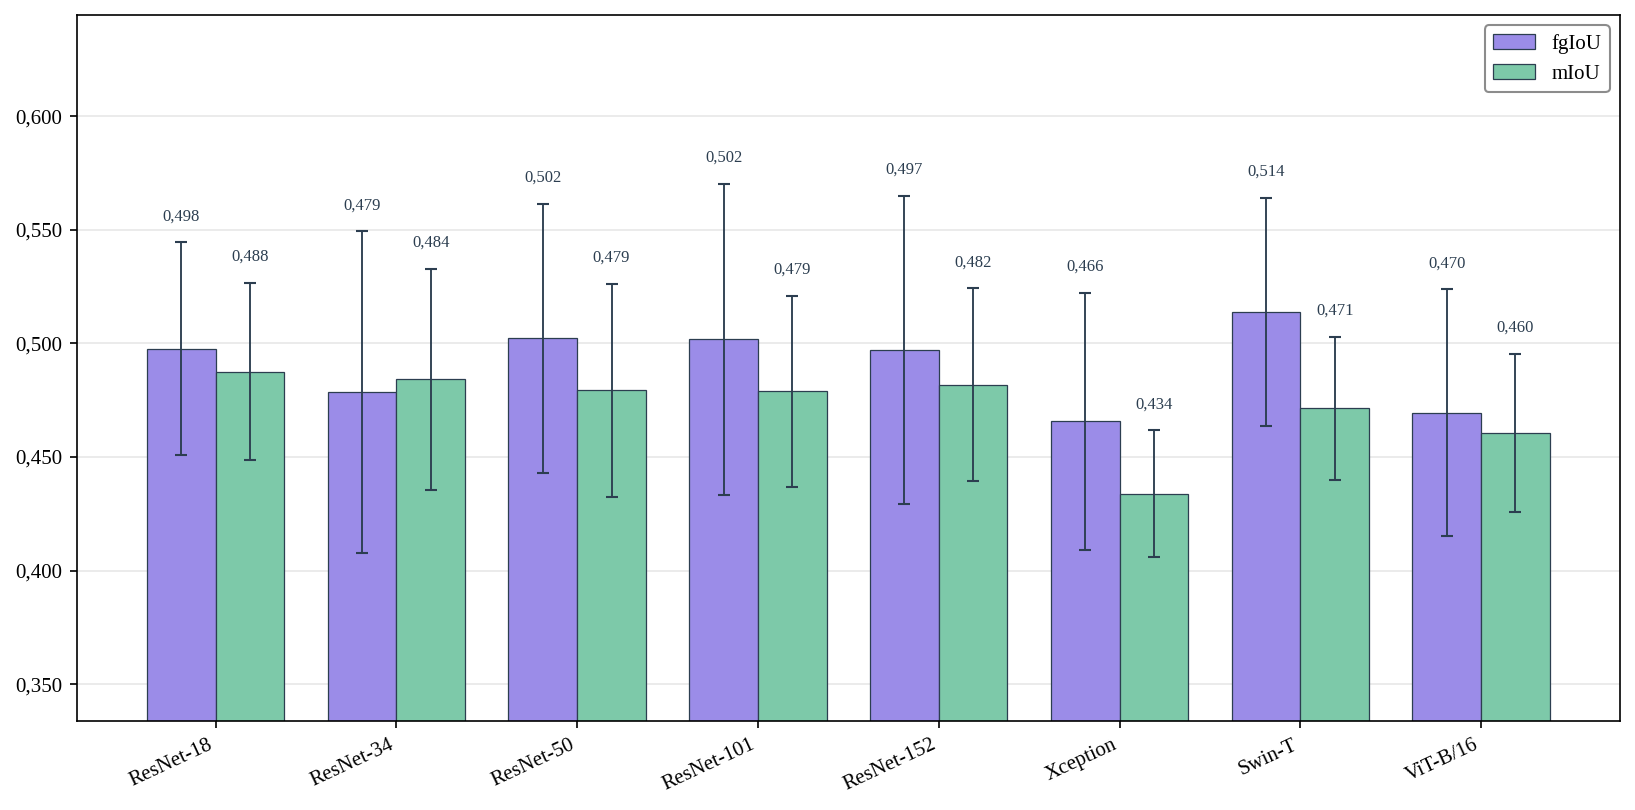

In [9]:
backbones = ["ResNet18", "ResNet34", "ResNet50", "ResNet101", "ResNet152",
             "Xception", "SwinT", "ViTB16"]
display_labels = ["ResNet-18", "ResNet-34", "ResNet-50", "ResNet-101", "ResNet-152",
                  "Xception", "Swin-T", "ViT-B/16"]

stats = [get_stats(bb, "ImageNetV1", "none") for bb in backbones]
fg_means = [s["fgIoU_mean"] for s in stats]
fg_stds  = [s["fgIoU_std"]  for s in stats]
mi_means = [s["mIoU_mean"]  for s in stats]
mi_stds  = [s["mIoU_std"]   for s in stats]

x = np.arange(len(backbones))
width = 0.38

fig, ax = plt.subplots(figsize=(11, 5.5))

b1 = ax.bar(x - width/2, fg_means, width, yerr=fg_stds, label="fgIoU",
            color=COLORS["fgIoU"], edgecolor="#2c3e50", linewidth=0.6,
            capsize=3, error_kw=dict(lw=0.9, ecolor="#2c3e50"))
b2 = ax.bar(x + width/2, mi_means, width, yerr=mi_stds, label="mIoU",
            color=COLORS["mIoU"], edgecolor="#2c3e50", linewidth=0.6,
            capsize=3, error_kw=dict(lw=0.9, ecolor="#2c3e50"))

# Data labels (virgüllü)
# Data labels — std çubuklarının ÜSTÜNDE
for bar, val, std in zip(b1, fg_means, fg_stds):
    ax.text(bar.get_x() + bar.get_width()/2, val + std + 0.008,
            f"{val:.3f}".replace(".", ","), ha="center", va="bottom",
            fontsize=8, color="#2c3e50")
for bar, val, std in zip(b2, mi_means, mi_stds):
    ax.text(bar.get_x() + bar.get_width()/2, val + std + 0.008,
            f"{val:.3f}".replace(".", ","), ha="center", va="bottom",
            fontsize=8, color="#2c3e50")

ax.set_xticks(x)
ax.set_xticklabels(display_labels, rotation=25, ha="right")
#ax.set_ylabel("Değer", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(tr_format))
ax.grid(True, axis="y", alpha=0.3)
ax.set_axisbelow(True)
ax.legend(loc="upper right", fontsize=10, framealpha=0.9, edgecolor="gray")

# Hafif y-axis padding
ax.set_ylim(bottom=max(0, min(fg_means + mi_means) - 0.10),
            top=max(fg_means + mi_means) + max(fg_stds + mi_stds) + 0.06)

plt.tight_layout()
path = FIGURES_DIR / "Exp_backbone_chart.png"
fig.savefig(path, dpi=300, bbox_inches="tight")
print(f"Kaydedildi: {path}")
plt.show()


### 3. Grafik 2 — Katman Açma (ResNet-18 ve ResNet-50)

Kaydedildi: /home/zehra/Desktop/woodland/figures/quantitative_results/Exp_unfreeze_chart.png
Renkler: fgIoU = #9B8CE8, mIoU = #7DC9A9
Y aralığı: 0,375 – 0,620


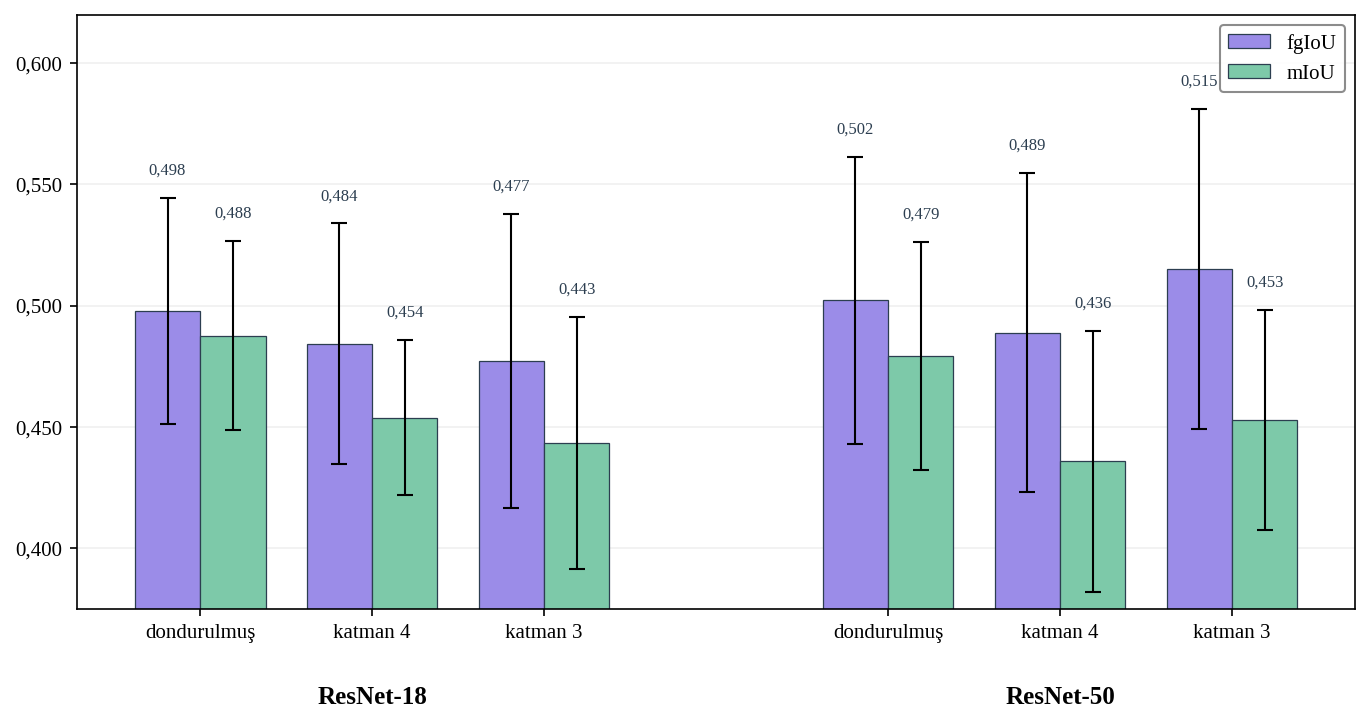

In [17]:
# Exp 1 (omurga) ile birebir aynı biçim — 2 grup × 3 yapılandırma × 2 metrik
config_labels = ["dondurulmuş", "katman 4", "katman 3"]  # BOŞLUKLU
strategies = ["none", "layer4", "layer3"]

r18_stats = [get_stats("ResNet18", "ImageNetV1", s) for s in strategies]
r50_stats = [get_stats("ResNet50", "ImageNetV1", s) for s in strategies]

r18_fg  = [s["fgIoU_mean"] for s in r18_stats]
r18_fgs = [s["fgIoU_std"]  for s in r18_stats]
r18_mi  = [s["mIoU_mean"]  for s in r18_stats]
r18_mis = [s["mIoU_std"]   for s in r18_stats]
r50_fg  = [s["fgIoU_mean"] for s in r50_stats]
r50_fgs = [s["fgIoU_std"]  for s in r50_stats]
r50_mi  = [s["mIoU_mean"]  for s in r50_stats]
r50_mis = [s["mIoU_std"]   for s in r50_stats]

color_fg = "#9B8CE8"  # lavanta
color_mi = "#7DC9A9"  # mint

r18_x = np.arange(3)
r50_x = np.arange(3) + 4.0
width = 0.38

fig, ax = plt.subplots(figsize=(11, 5.5))

# ResNet-18 grubu
b1 = ax.bar(r18_x - width/2, r18_fg, width, yerr=r18_fgs, label="fgIoU",
            color=color_fg, edgecolor="#2c3e50", linewidth=0.6,
            capsize=4, error_kw=dict(lw=1.0, ecolor="black"))
b2 = ax.bar(r18_x + width/2, r18_mi, width, yerr=r18_mis, label="mIoU",
            color=color_mi, edgecolor="#2c3e50", linewidth=0.6,
            capsize=4, error_kw=dict(lw=1.0, ecolor="black"))

# ResNet-50 grubu (legend tekrarı olmasın)
b3 = ax.bar(r50_x - width/2, r50_fg, width, yerr=r50_fgs,
            color=color_fg, edgecolor="#2c3e50", linewidth=0.6,
            capsize=4, error_kw=dict(lw=1.0, ecolor="black"))
b4 = ax.bar(r50_x + width/2, r50_mi, width, yerr=r50_mis,
            color=color_mi, edgecolor="#2c3e50", linewidth=0.6,
            capsize=4, error_kw=dict(lw=1.0, ecolor="black"))

# Data labels — std çubuklarının ÜSTÜNDE (Exp 1 ile aynı stil)
def add_labels(bars, vals, stds):
    for bar, val, std in zip(bars, vals, stds):
        ax.text(bar.get_x() + bar.get_width()/2, val + std + 0.008,
                f"{val:.3f}".replace(".", ","), ha="center", va="bottom",
                fontsize=8, color="#2c3e50")

add_labels(b1, r18_fg, r18_fgs)
add_labels(b2, r18_mi, r18_mis)
add_labels(b3, r50_fg, r50_fgs)
add_labels(b4, r50_mi, r50_mis)

# X tick (alt satır): yapılandırma isimleri
all_x = list(r18_x) + list(r50_x)
ax.set_xticks(all_x)
ax.set_xticklabels(config_labels + config_labels, fontsize=10)

# Grup başlıkları (üst satır)
group_centers = [(r18_x[0] + r18_x[-1]) / 2, (r50_x[0] + r50_x[-1]) / 2]
for gx, label in zip(group_centers, ["ResNet-18", "ResNet-50"]):
    ax.annotate(label, xy=(gx, -0.13),
                xycoords=("data", "axes fraction"),
                ha="center", va="top",
                fontsize=12, fontweight="bold")

# Y ekseni — Türkçe virgüllü ondalık
#ax.set_ylabel("Değer", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x:.3f}".replace(".", ",")
))
# Label'ların yer tutması için üst sınır biraz genişletildi
ax.set_ylim(0.375, 0.620)

ax.grid(True, axis="y", alpha=0.3, color="#cccccc")
ax.set_axisbelow(True)

ax.legend(loc="upper right", fontsize=10, framealpha=0.9, edgecolor="gray")

plt.subplots_adjust(bottom=0.16)

path = FIGURES_DIR / "Exp_unfreeze_chart.png"
fig.savefig(path, dpi=300, bbox_inches="tight")
print(f"Kaydedildi: {path}")
print(f"Renkler: fgIoU = {color_fg}, mIoU = {color_mi}")
print(f"Y aralığı: 0,375 – 0,620")
plt.show()


### 4. Grafik 3 — Aşama Açma (Swin-T)

Kaydedildi: /home/zehra/Desktop/woodland/figures/quantitative_results/Exp_swin_unfreeze_chart.png

Renkler: fgIoU = #9B8CE8, mIoU = #7DC9A9
Y aralığı: 0,375 – 0,620

Değerler (5-fold ortalama ± std):
  Swin-T + dondurulmuş   fgIoU = 0.514 ± 0.050  |  mIoU = 0.471 ± 0.031
  Swin-T + aşama 4       fgIoU = 0.521 ± 0.047  |  mIoU = 0.478 ± 0.029
  Swin-T + aşama 3       fgIoU = 0.521 ± 0.048  |  mIoU = 0.480 ± 0.029


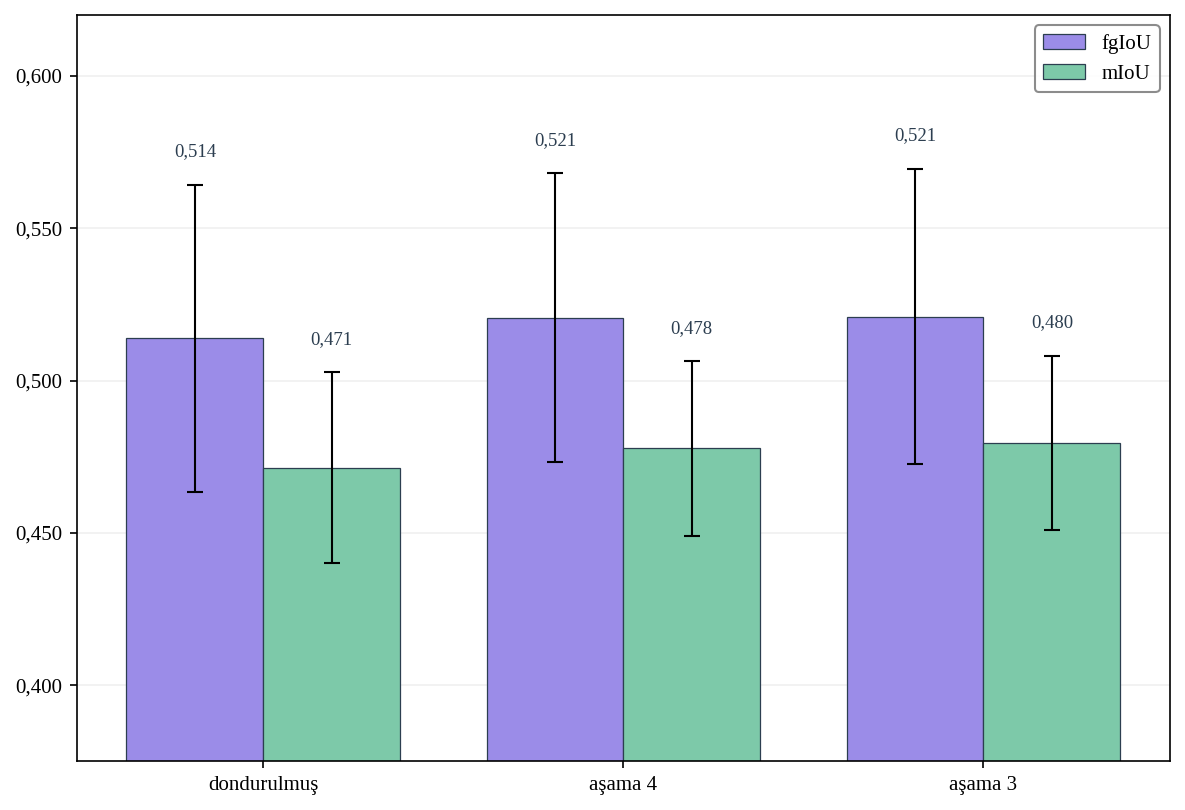

In [19]:
# Exp 1 ile aynı stil — Swin-T × 3 yapılandırma × 2 metrik
strategies = ["none", "stage4", "stage3"]
display_labels = ["dondurulmuş", "aşama 4", "aşama 3"]

stats = [get_stats("SwinT", "ImageNetV1", s) for s in strategies]
fg_means = [s["fgIoU_mean"] for s in stats]
fg_stds  = [s["fgIoU_std"]  for s in stats]
mi_means = [s["mIoU_mean"]  for s in stats]
mi_stds  = [s["mIoU_std"]   for s in stats]

# Exp 1 ile aynı renkler
color_fg = "#9B8CE8"  # lavanta
color_mi = "#7DC9A9"  # mint

x = np.arange(len(strategies))
width = 0.38

fig, ax = plt.subplots(figsize=(8, 5.5))

b1 = ax.bar(x - width/2, fg_means, width, yerr=fg_stds, label="fgIoU",
            color=color_fg, edgecolor="#2c3e50", linewidth=0.6,
            capsize=4, error_kw=dict(lw=1.0, ecolor="black"))
b2 = ax.bar(x + width/2, mi_means, width, yerr=mi_stds, label="mIoU",
            color=color_mi, edgecolor="#2c3e50", linewidth=0.6,
            capsize=4, error_kw=dict(lw=1.0, ecolor="black"))

# Data labels — std çubuklarının ÜSTÜNDE
for bar, val, std in zip(b1, fg_means, fg_stds):
    ax.text(bar.get_x() + bar.get_width()/2, val + std + 0.008,
            f"{val:.3f}".replace(".", ","), ha="center", va="bottom",
            fontsize=9, color="#2c3e50")
for bar, val, std in zip(b2, mi_means, mi_stds):
    ax.text(bar.get_x() + bar.get_width()/2, val + std + 0.008,
            f"{val:.3f}".replace(".", ","), ha="center", va="bottom",
            fontsize=9, color="#2c3e50")

ax.set_xticks(x)
ax.set_xticklabels(display_labels, fontsize=10)
#ax.set_ylabel("Değer", fontsize=11)

# Türkçe virgüllü ondalık
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x:.3f}".replace(".", ",")
))

# Grafik 2 ile uyumlu y-aralığı
ax.set_ylim(0.375, 0.620)

ax.grid(True, axis="y", alpha=0.3, color="#cccccc")
ax.set_axisbelow(True)
ax.legend(loc="upper right", fontsize=10, framealpha=0.9, edgecolor="gray")

plt.tight_layout()
path = FIGURES_DIR / "Exp_swin_unfreeze_chart.png"
fig.savefig(path, dpi=300, bbox_inches="tight")
print(f"Kaydedildi: {path}")
print(f"\nRenkler: fgIoU = {color_fg}, mIoU = {color_mi}")
print(f"Y aralığı: 0,375 – 0,620")
print(f"\nDeğerler (5-fold ortalama ± std):")
for cfg, f, fs, m, ms in zip(display_labels, fg_means, fg_stds, mi_means, mi_stds):
    print(f"  Swin-T + {cfg:<12}  fgIoU = {f:.3f} ± {fs:.3f}  |  mIoU = {m:.3f} ± {ms:.3f}")
plt.show()


### 5. Grafik 4 — Ön Eğitimli Ağırlık Karşılaştırması (ResNet-50)

Kaydedildi: /home/zehra/Desktop/woodland/figures/quantitative_results/Exp_pretrained_chart.png

Renkler: fgIoU = #9B8CE8, mIoU = #7DC9A9
Y aralığı: (0.3789123459578664, 0.656397048078392)

Değerler (5-fold ortalama ± std):
  ResNet-50 + ImageNet V1    fgIoU = 0.502 ± 0.059  |  mIoU = 0.479 ± 0.047
  ResNet-50 + Million-AID    fgIoU = 0.498 ± 0.065  |  mIoU = 0.465 ± 0.031
  ResNet-50 + BigEarthNet    fgIoU = 0.453 ± 0.054  |  mIoU = 0.451 ± 0.027
  ResNet-50 + SeCo           fgIoU = 0.556 ± 0.071  |  mIoU = 0.543 ± 0.051
  ResNet-50 + Cityscapes     fgIoU = 0.485 ± 0.051  |  mIoU = 0.482 ± 0.030


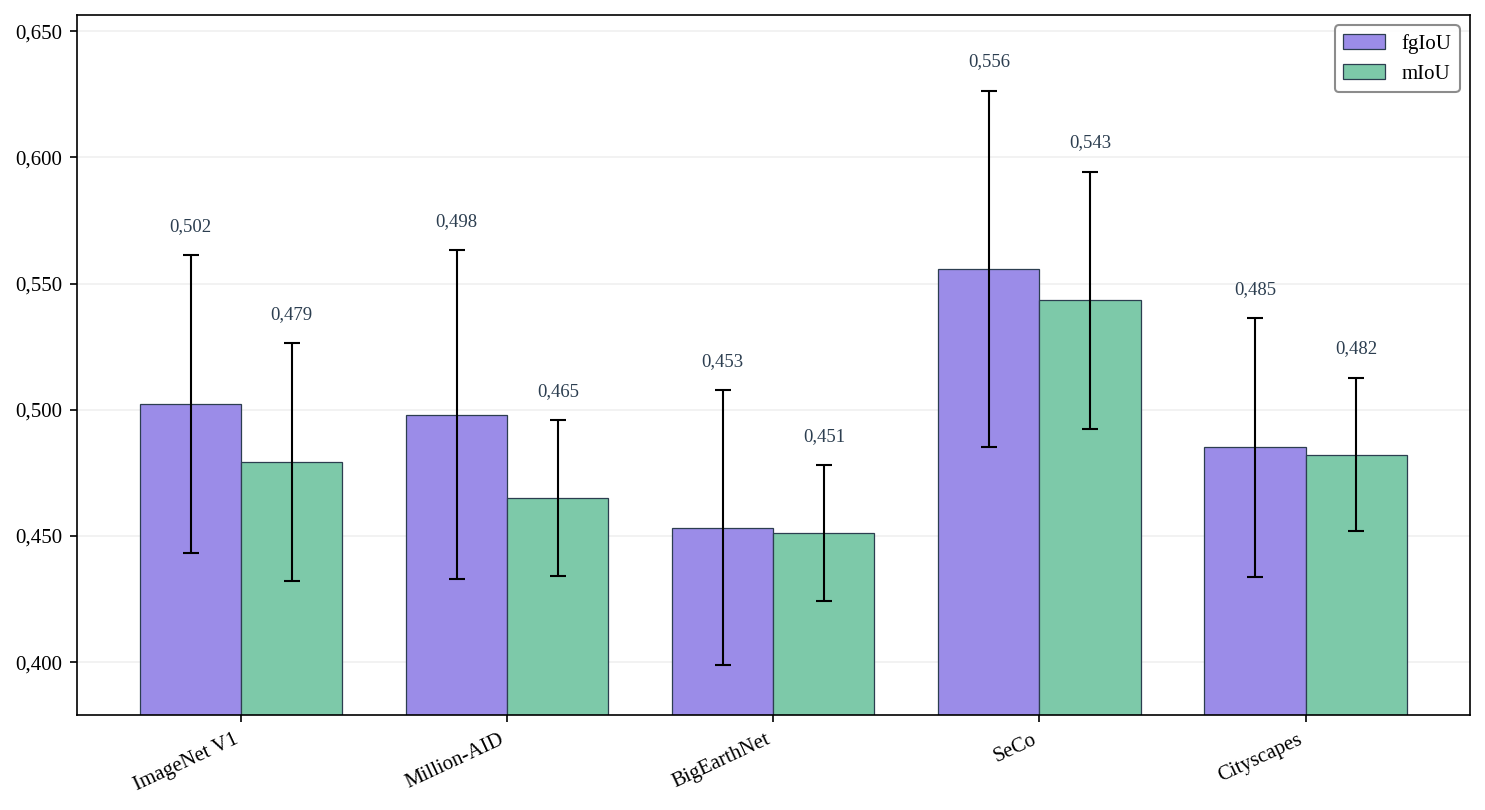

In [22]:
# Exp 1 ile aynı stil — ResNet-50 × 5 ön eğitim kaynağı × 2 metrik
sources = ["ImageNetV1", "MillionAID", "BigEarthNet", "SeCo", "Cityscapes"]
display_labels = ["ImageNet V1", "Million-AID", "BigEarthNet", "SeCo", "Cityscapes"]

stats = [get_stats("ResNet50", src, "none") for src in sources]
fg_means = [s["fgIoU_mean"] for s in stats]
fg_stds  = [s["fgIoU_std"]  for s in stats]
mi_means = [s["mIoU_mean"]  for s in stats]
mi_stds  = [s["mIoU_std"]   for s in stats]

# Exp 1 ile aynı renkler
color_fg = "#9B8CE8"  # lavanta
color_mi = "#7DC9A9"  # mint

x = np.arange(len(sources))
width = 0.38

fig, ax = plt.subplots(figsize=(10, 5.5))

b1 = ax.bar(x - width/2, fg_means, width, yerr=fg_stds, label="fgIoU",
            color=color_fg, edgecolor="#2c3e50", linewidth=0.6,
            capsize=4, error_kw=dict(lw=1.0, ecolor="black"))
b2 = ax.bar(x + width/2, mi_means, width, yerr=mi_stds, label="mIoU",
            color=color_mi, edgecolor="#2c3e50", linewidth=0.6,
            capsize=4, error_kw=dict(lw=1.0, ecolor="black"))

# Data labels — std çubuklarının ÜSTÜNDE
for bar, val, std in zip(b1, fg_means, fg_stds):
    ax.text(bar.get_x() + bar.get_width()/2, val + std + 0.008,
            f"{val:.3f}".replace(".", ","), ha="center", va="bottom",
            fontsize=9, color="#2c3e50")
for bar, val, std in zip(b2, mi_means, mi_stds):
    ax.text(bar.get_x() + bar.get_width()/2, val + std + 0.008,
            f"{val:.3f}".replace(".", ","), ha="center", va="bottom",
            fontsize=9, color="#2c3e50")

ax.set_xticks(x)
ax.set_xticklabels(display_labels, fontsize=10, rotation=25, ha="right")
#ax.set_ylabel("Değer", fontsize=11)

# Türkçe virgüllü ondalık
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x:.3f}".replace(".", ",")
))

# SeCo en yüksek (~0,63 std dahil), label için ek boşluk
all_tops = [m + s for m, s in zip(fg_means + mi_means, fg_stds + mi_stds)]
all_bots = [m - s for m, s in zip(fg_means + mi_means, fg_stds + mi_stds)]
ax.set_ylim(min(all_bots) - 0.02, max(all_tops) + 0.03)

ax.grid(True, axis="y", alpha=0.3, color="#cccccc")
ax.set_axisbelow(True)
ax.legend(loc="upper right", fontsize=10, framealpha=0.9, edgecolor="gray")

plt.tight_layout()
path = FIGURES_DIR / "Exp_pretrained_chart.png"
fig.savefig(path, dpi=300, bbox_inches="tight")
print(f"Kaydedildi: {path}")
print(f"\nRenkler: fgIoU = {color_fg}, mIoU = {color_mi}")
print(f"Y aralığı: {ax.get_ylim()}")
print(f"\nDeğerler (5-fold ortalama ± std):")
for src, f, fs, m, ms in zip(display_labels, fg_means, fg_stds, mi_means, mi_stds):
    print(f"  ResNet-50 + {src:<13}  fgIoU = {f:.3f} ± {fs:.3f}  |  mIoU = {m:.3f} ± {ms:.3f}")
plt.show()
